# PHASE 1: LOADING DATA

In [2]:
!pip install docling langchain-core langchain-community opencv-python-headless
!pip install transformers torch torchvision 
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

print("Environment Ready.")

Environment Ready.


In [3]:
import pandas as pd
import os

base_dir = '/kaggle/input/datasets/raddar/chest-xrays-indiana-university' 
reports_csv = os.path.join(base_dir, 'indiana_reports.csv')
projections_csv = os.path.join(base_dir, 'indiana_projections.csv')

reports_df = pd.read_csv(reports_csv)
projections_df = pd.read_csv(projections_csv)

def parse_clinical_report_csv(uid):
    """
    Fetches the findings, impression, and associated images for a given report UID.
    """
    report_data = {
        "uid": uid,
        "image_filenames": [],
        "findings": "Not provided",
        "impression": "Not provided"
    }
    
    # 1. Locate the text report for this UID
    report_row = reports_df[reports_df['uid'] == uid]
    
    if not report_row.empty:
        # Extract findings and impression, handling potential NaN (empty) values
        findings = report_row.iloc[0]['findings']
        impression = report_row.iloc[0]['impression']
        
        report_data["findings"] = findings if pd.notna(findings) else "Not provided"
        report_data["impression"] = impression if pd.notna(impression) else "Not provided"
        
    # 2. Locate all images associated with this UID in the projections table
    image_rows = projections_df[projections_df['uid'] == uid]
    if not image_rows.empty:
        report_data["image_filenames"] = image_rows['filename'].tolist()
        
    return report_data

sample_uid = reports_df['uid'].iloc[0]
sample_data = parse_clinical_report_csv(sample_uid)

print("Parsed Report Data:")
print(f"UID: {sample_data['uid']}")
print(f"Associated Images: {sample_data['image_filenames']}")
print(f"Findings: {sample_data['findings']}")
print(f"Impression: {sample_data['impression']}")

Parsed Report Data:
UID: 1
Associated Images: ['1_IM-0001-4001.dcm.png', '1_IM-0001-3001.dcm.png']
Findings: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.
Impression: Normal chest x-XXXX.


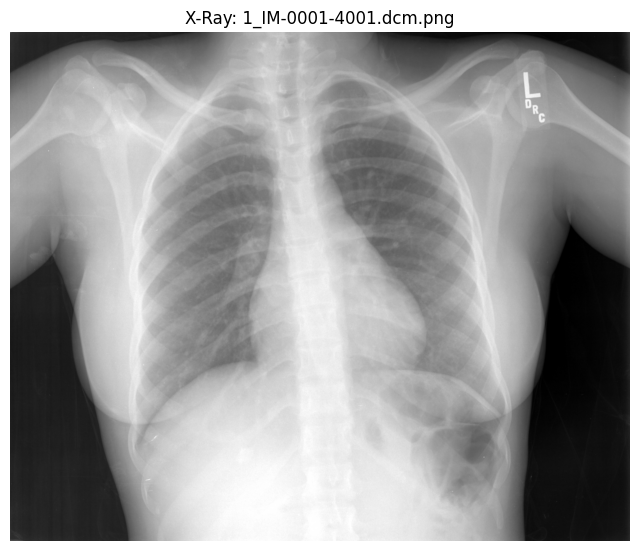

In [5]:
image_dir = os.path.join(base_dir, 'images', 'images_normalized')

if sample_data["image_filenames"]:
    # Grab the first image associated with the report
    img_filename = sample_data["image_filenames"][0]
    img_path = os.path.join(image_dir, img_filename)
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.figure(figsize=(8,8))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(f"X-Ray: {img_filename}")
        plt.show()
    else:
        print(f"Image {img_filename} not found in {image_dir}")
else:
    print("No images associated with this report.")

# PHASE 2: VISION LAYER TESTING

In [6]:
!pip install ultralytics
import cv2
from ultralytics import YOLO
import matplotlib.patches as patches

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
# Load a pre-trained YOLO model (downloads automatically in Kaggle if internet is on)
# We use a 'nano' or 'small' model first for rapid testing
model = YOLO('yolov8n.pt') 

print("Vision Model Loaded.")

Vision Model Loaded.



image 1/1 /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/1_IM-0001-4001.dcm.png: 544x640 1 person, 58.8ms
Speed: 10.5ms preprocess, 58.8ms inference, 29.7ms postprocess per image at shape (1, 3, 544, 640)


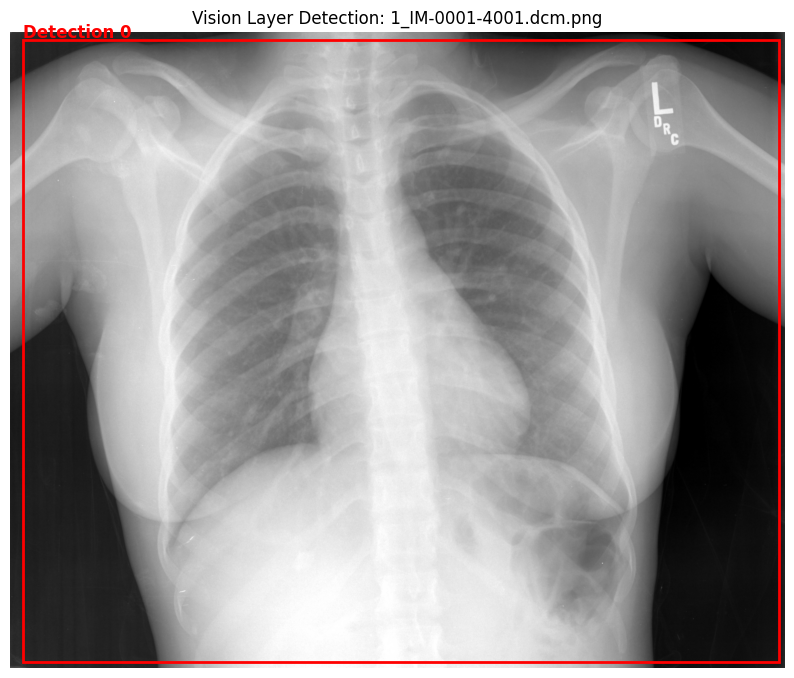

Detected 1 regions of interest.


In [8]:
# Ensure we have the image path from your previous pandas data dictionary
if sample_data["image_filenames"]:
    img_filename = sample_data["image_filenames"][0]
    img_path = os.path.join(image_dir, img_filename)
    
    # 1. Run inference on the X-Ray
    results = model(img_path)
    
    # 2. Load image for plotting
    img = mpimg.imread(img_path)
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    # 3. Extract bounding boxes and plot them
    boxes = results[0].boxes.xyxy.cpu().numpy() # Get coordinates (x1, y1, x2, y2)
    classes = results[0].boxes.cls.cpu().numpy() # Get class IDs
    
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1
        
        # Create a Rectangle patch
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
        # Optional: Add label (will be generic COCO labels for now until fine-tuned)
        ax.text(x1, y1-5, f"Detection {int(classes[i])}", color='red', fontsize=12, weight='bold')

    plt.title(f"Vision Layer Detection: {img_filename}")
    plt.show()
    
    print(f"Detected {len(boxes)} regions of interest.")

# PHASE 3: FINE-TUNING YOLO

In [15]:
import yaml
import os
import glob
from ultralytics import YOLO

# 1. Automatically hunt down the data.yaml file anywhere in the Kaggle input directory
print("Hunting for dataset...")
yaml_files = glob.glob('/kaggle/input/**/data.yaml', recursive=True)

if not yaml_files:
    print("❌ Could not find data.yaml! Double check that the dataset is mounted in the right panel.")
else:
    # Get the exact path where the dataset actually lives
    original_yaml = yaml_files[0]
    base_dataset_dir = os.path.dirname(original_yaml)
    print(f"✅ Found dataset exactly at: {base_dataset_dir}")

    # 2. Read their messy configuration
    with open(original_yaml, 'r') as file:
        yaml_data = yaml.safe_load(file)

    # 3. Force the paths to be the exact, absolute paths we just auto-discovered
    yaml_data['train'] = os.path.join(base_dataset_dir, 'train')
    yaml_data['val'] = os.path.join(base_dataset_dir, 'val')
    
    # Safely handle the test folder (YOLO will crash if it expects a test folder that isn't there)
    if os.path.exists(os.path.join(base_dataset_dir, 'test')):
        yaml_data['test'] = os.path.join(base_dataset_dir, 'test')
    elif 'test' in yaml_data:
        del yaml_data['test'] 

    # 4. Save the bulletproof YAML to your working directory
    working_yaml_path = '/kaggle/working/bulletproof_medical_data.yaml'
    with open(working_yaml_path, 'w') as file:
        yaml.dump(yaml_data, file)

    print(f"✅ Bulletproof YAML saved to {working_yaml_path}")
    print("🚀 Starting YOLO Training...")

    # 5. Initialize and run the training loop
    model = YOLO('yolov8s.pt')
    
    results = model.train(
        data=working_yaml_path,
        epochs=25,                  
        imgsz=512,                  
        batch=16,                   
        device=0,                   
        project='/kaggle/working/', 
        name='medical_yolo_run',
        workers=2                   
    )

Hunting for dataset...
✅ Found dataset exactly at: /kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled
✅ Bulletproof YAML saved to /kaggle/working/bulletproof_medical_data.yaml
🚀 Starting YOLO Training...
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bulletproof_medical_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=


image 1/1 /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/1_IM-0001-4001.dcm.png: 448x512 1 No finding, 11.2ms
Speed: 2.0ms preprocess, 11.2ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 512)


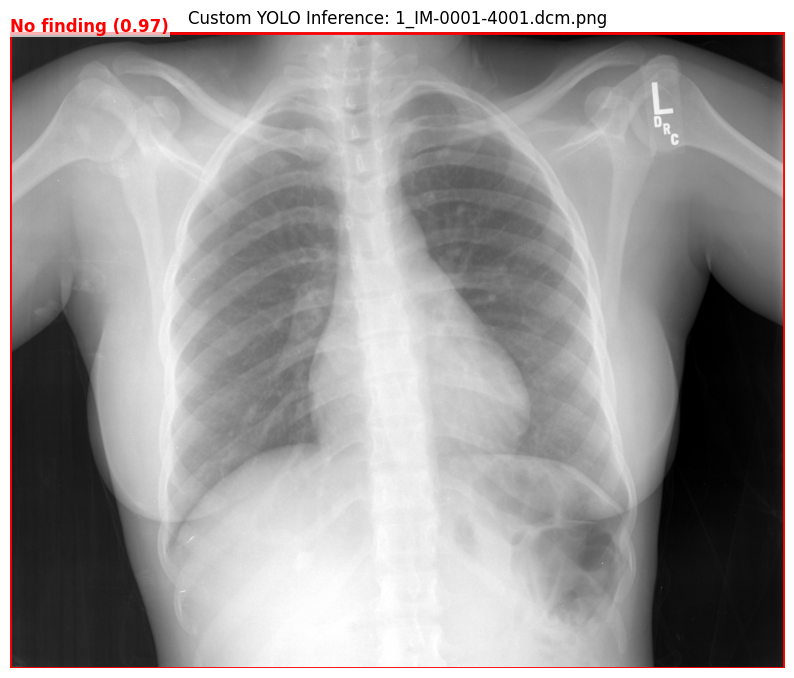

Vision Layer Output: Detected []


In [18]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import os

my_medical_model = YOLO('/kaggle/working/medical_yolo_run-2/weights/best.pt')

if sample_data["image_filenames"]:
    img_filename = sample_data["image_filenames"][0]
    img_path = os.path.join(image_dir, img_filename)
    
    # 3. Run inference!
    # conf=0.25 filters out low-confidence guesses
    results = my_medical_model(img_path, conf=0.25) 
    
    # 4. Plot the results
    img = mpimg.imread(img_path)
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    boxes = results[0].boxes.xyxy.cpu().numpy() 
    classes = results[0].boxes.cls.cpu().numpy()
    confidences = results[0].boxes.conf.cpu().numpy()
    
    detected_findings = []

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1
        
        # Grab the medical name you just trained it to recognize
        class_id = int(classes[i])
        anomaly_name = my_medical_model.names[class_id]
        if anomaly_name != "No finding":
            detected_findings.append(anomaly_name)
            
            # Draw the box
            rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            
            # Add label
            label_text = f"{anomaly_name} ({confidences[i]:.2f})"
            ax.text(x1, y1-5, label_text, color='red', fontsize=12, weight='bold', 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        
        # Draw the box
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        
        # Add label
        label_text = f"{anomaly_name} ({confidences[i]:.2f})"
        ax.text(x1, y1-5, label_text, color='red', fontsize=12, weight='bold', 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    plt.title(f"Custom YOLO Inference: {img_filename}")
    plt.show()
    
    print(f"Vision Layer Output: Detected {detected_findings}")

# PHASE 4: STRESS TESTING

Running Inference on 6 random images...


/tmp/ipykernel_57/2748602874.py:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


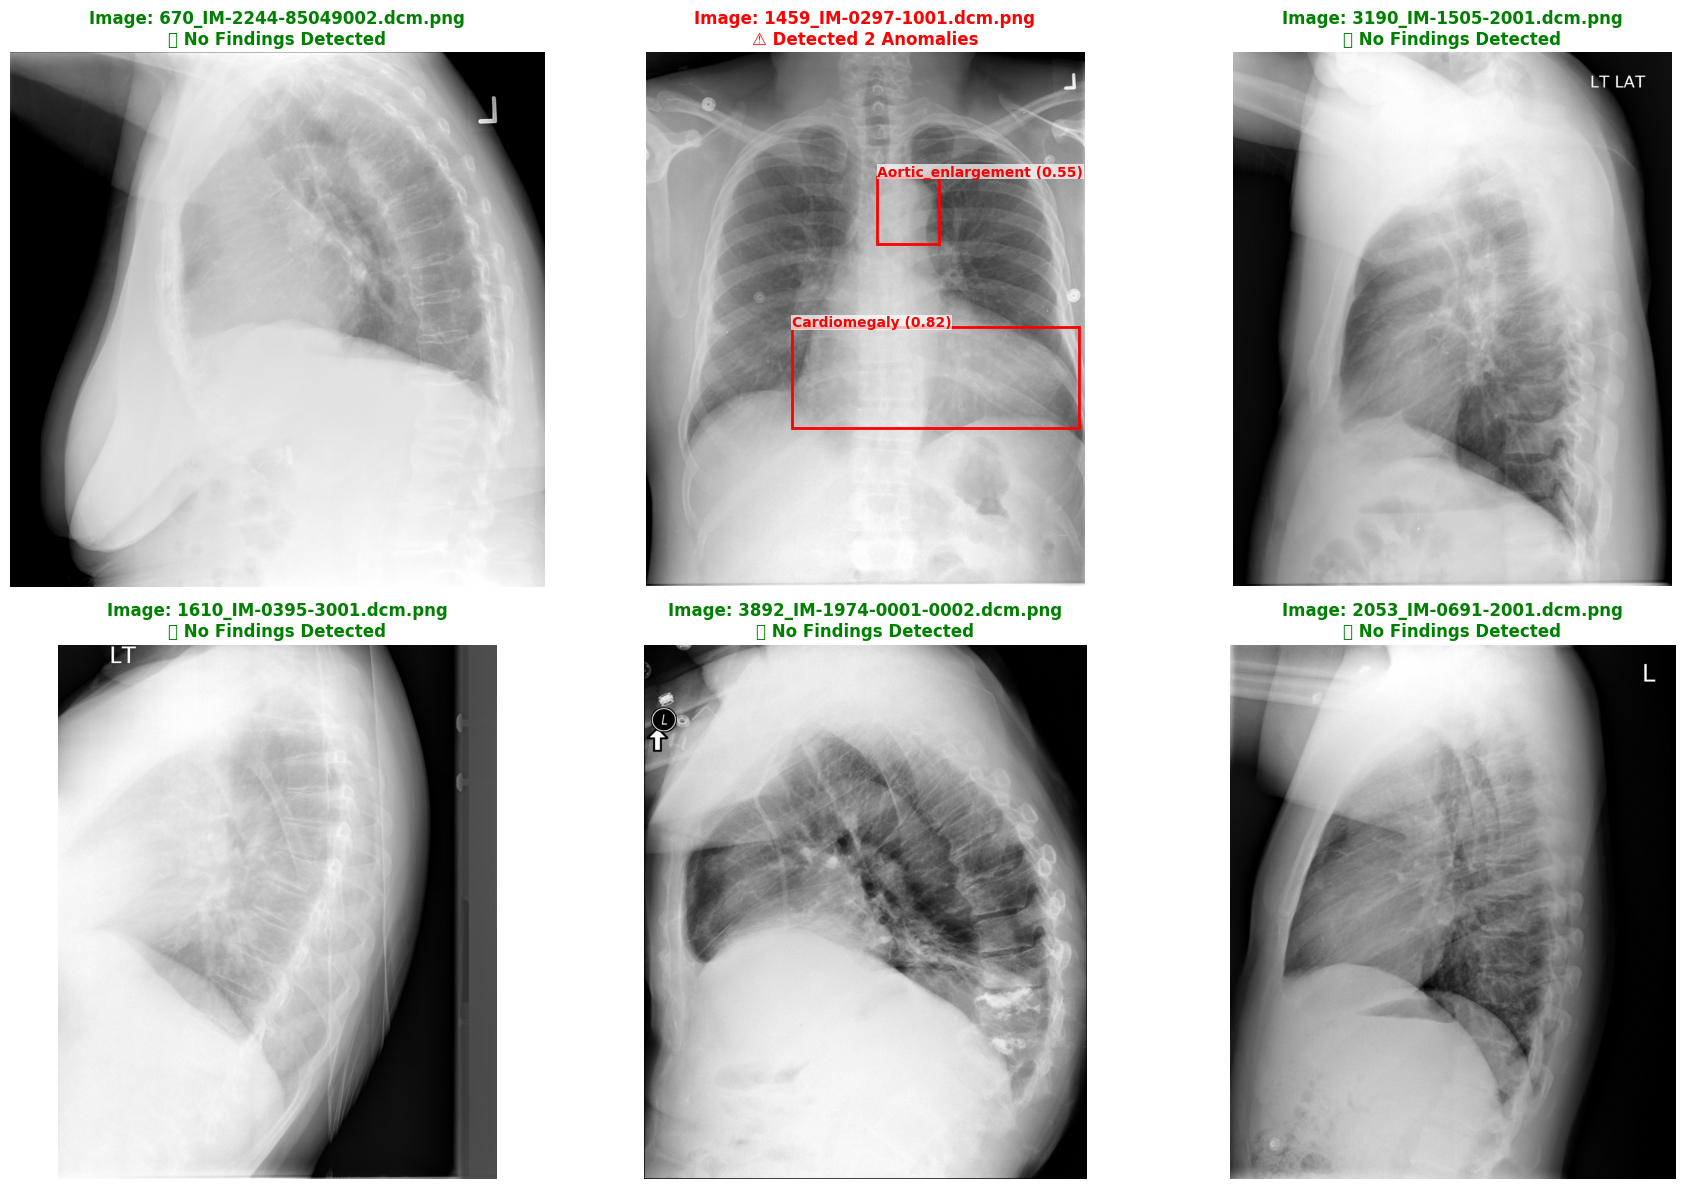

In [20]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from ultralytics import YOLO

# 1. Configuration
# Assuming 'image_dir' from Phase 1 is still in memory. If not, redefine it:
# image_dir = '/kaggle/input/chest-xrays-indiana-university/images/images_normalized'
model = YOLO('/kaggle/working/medical_yolo_run-2/weights/best.pt')
confidence_threshold = 0.25 # Only show relatively confident predictions
num_images_to_test = 6

# 2. Grab a random sample of images
all_images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
sample_images = random.sample(all_images, num_images_to_test)

# 3. Setup the Matplotlib Grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

print(f"Running Inference on {num_images_to_test} random images...")

for idx, img_filename in enumerate(sample_images):
    img_path = os.path.join(image_dir, img_filename)
    ax = axes[idx]
    
    # Run YOLO
    results = model(img_path, conf=confidence_threshold, verbose=False)
    
    # Load and show image
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    # Extract data
    boxes = results[0].boxes.xyxy.cpu().numpy()
    classes = results[0].boxes.cls.cpu().numpy()
    confidences = results[0].boxes.conf.cpu().numpy()
    
    findings_count = 0
    
    # Draw boxes
    for i, box in enumerate(boxes):
        class_id = int(classes[i])
        anomaly_name = model.names[class_id]
        
        if anomaly_name != "No finding":
            findings_count += 1
            x1, y1, x2, y2 = box
            width, height = x2 - x1, y2 - y1
            
            # Draw box
            rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            
            # Draw label
            label_text = f"{anomaly_name} ({confidences[i]:.2f})"
            ax.text(x1, y1-5, label_text, color='red', fontsize=10, weight='bold', 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))
    
    # Title logic
    if findings_count == 0:
        ax.set_title(f"Image: {img_filename}\n✅ No Findings Detected", color='green', weight='bold')
    else:
        ax.set_title(f"Image: {img_filename}\n⚠️ Detected {findings_count} Anomalies", color='red', weight='bold')

plt.tight_layout()
plt.show()

# PHASE 5: LANGCHAIN ORCHESTRATOR

In [21]:
!pip install langchain-mistralai

In [25]:
!pip install -q langchain-google-genai langchain langchain-core

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 790.4/790.4 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 19.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1

In [30]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")

In [32]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
import os

# 1. Pull the secret from Kaggle's vault
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")

# 2. THE MISSING LINK: Set the environment variable so LangChain can find it
os.environ["GOOGLE_API_KEY"] = secret_value_0
# Initialize Gemini 2.5 Flash 
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

prompt_template = """
You are an expert medical communicator. Your task is to translate a dense radiologist report into a plain-language summary for a patient.

Here is the clinical report:
Findings: {clinical_findings}
Impression: {clinical_impression}

Here are the anomalies detected by our Computer Vision model on the patient's X-ray:
Detected Visual Anomalies: {vision_detections}

Instructions:
1. Write a patient-friendly summary of the Impression at a 6th-grade reading level.
2. If the Vision model detected an anomaly that matches the text report, explicitly mention that our AI also saw it on the scan.
3. If the report says everything is normal, reassure the patient clearly.
4. Do not provide medical advice or diagnoses. Add a disclaimer to consult a physician.

Patient Summary:
"""

prompt = PromptTemplate(
    input_variables=["clinical_findings", "clinical_impression", "vision_detections"],
    template=prompt_template,
)

chain = prompt | llm

# Let's test it using a simulated "Cardiomegaly" case based on your successful vision output
test_inputs = {
    "clinical_findings": "The heart size is enlarged. The aorta is tortuous and unfolded. Lungs are clear without focal consolidation, effusion, or pneumothorax.",
    "clinical_impression": "Cardiomegaly and aortic unfolding. No acute pulmonary disease.",
    "vision_detections": "Cardiomegaly, Aortic_enlargement" # Simulating the output from your top-middle image!
}

print("Generating Multimodal Patient Summary...\n")
response = chain.invoke(test_inputs)
print(response.content)

Generating Multimodal Patient Summary...

Here is a summary of your X-ray report:

Your X-ray shows that your heart looks a bit larger than usual. Our AI system also saw that your heart appears enlarged on the scan.

It also shows that a main blood vessel called the aorta, which carries blood from your heart, appears a bit stretched out or unfolded. Our AI system also noted that your aorta appeared enlarged on the scan.

Good news is that your lungs look clear, and there are no signs of any new or serious lung problems right now.

This summary is for your information only and is not a diagnosis or medical advice. Please discuss these findings with your doctor, who can explain what they mean for your health and next steps.
